# Baseline y modelos preliminares

Este notebook desarrolla los puntos **7. Baseline**, **8. Modelos preliminares** y **9. Evaluación preliminar** del TP1. La formulación principal es clasificación multiclase (`Dropout`, `Enrolled`, `Graduate`); también se revisa la alternativa binaria `Dropout` vs. `No Dropout` planteada en el alcance.

La decisión de predicción ocurre al cierre del primer semestre: se excluyen las seis variables del segundo semestre. Se mantiene una prueba estratificada fija, y el preprocesamiento vive dentro de cada pipeline para que imputación, escalado y codificación se ajusten solo dentro de cada fold de entrenamiento.

## Datos y partición

Se vuelve a construir el conjunto elegible desde el CSV para que este notebook sea reproducible por sí mismo y no dependa del estado del kernel del notebook 02. La partición 80/20 conserva las proporciones de clase y se fija con `random_state=42`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")

DATA_PATH = Path("../data/raw/data.csv")
TARGET = "Target"
raw_df = pd.read_csv(DATA_PATH, sep=";")
raw_df.columns = raw_df.columns.str.strip()

y = raw_df[TARGET].copy()
second_semester_cols = [
    col for col in raw_df.columns
    if col.startswith("Curricular units 2nd sem")
]
X = raw_df.drop(columns=[TARGET, *second_semester_cols]).copy()

nominal_features = [
    "Marital status", "Application mode", "Course", "Previous qualification",
    "Nacionality", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
]
binary_features = [
    "Daytime/evening attendance", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International",
]
ordinal_features = ["Application order"]
numeric_features = [
    col for col in X.columns
    if col not in nominal_features + binary_features + ordinal_features
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

partition_summary = pd.concat(
    {
        "Completo": y.value_counts(normalize=True),
        "Entrenamiento": y_train.value_counts(normalize=True),
        "Prueba": y_test.value_counts(normalize=True),
    },
    axis=1,
).fillna(0).mul(100).rename_axis("Clase")
display(partition_summary.round(2))
display(pd.DataFrame({
    "Comprobación": [
        "Filas",
        "Predictores",
        "Columnas del 2.º semestre incluidas",
        "Target incluido en X",
    ],
    "Valor": [
        len(raw_df),
        X.shape[1],
        len(set(second_semester_cols).intersection(X.columns)),
        TARGET in X.columns,
    ],
}))

assert not set(second_semester_cols).intersection(X.columns)
assert TARGET not in X.columns
assert set(y.unique()) == {"Dropout", "Enrolled", "Graduate"}

,Completo,Entrenamiento,Prueba
Clase,,,
Graduate,49.93,49.93,49.94
Dropout,32.12,32.13,32.09
Enrolled,17.95,17.94,17.97


,Comprobación,Valor
0,Filas,4424
1,Predictores,30
2,Columnas del 2.º semestre incluidas,0
3,Target incluido en X,False


## 7. Baseline

El baseline multiclase será `DummyClassifier(strategy="most_frequent")`: predice siempre la clase mayoritaria de entrenamiento. Es una referencia transparente; su accuracy refleja únicamente el desbalance, mientras que el recall de `Dropout` será cero si `Dropout` no es la clase mayoritaria. El baseline binario usará la misma estrategia en la etiqueta `Dropout` vs. `No Dropout`.

## 8. Modelos preliminares

Se comparan dos familias con supuestos diferentes. La regresión logística ofrece una referencia lineal e interpretable; se usa ponderación balanceada para atender el costo de no detectar `Dropout`. El random forest captura relaciones no lineales e interacciones, también con ponderación por clase. Son modelos iniciales, no una búsqueda exhaustiva de hiperparámetros.

El `ColumnTransformer` reproduce la preparación de 02: imputación y one-hot para variables nominales, conservación de binarias y mediana más escalado para variables ordinales y cuantitativas. Como está dentro de cada `Pipeline`, cada fold de validación ajusta sus transformaciones solo sobre su propia partición de entrenamiento.

In [2]:
from sklearn.compose import ColumnTransformer


def build_preprocessor():
    nominal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    scaled_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    return ColumnTransformer(
        transformers=[
            ("nominal", nominal_pipeline, nominal_features),
            ("binary", SimpleImputer(strategy="most_frequent"), binary_features),
            ("ordinal", scaled_pipeline, ordinal_features),
            ("numeric", scaled_pipeline, numeric_features),
        ],
        remainder="drop",
    )


def build_pipeline(estimator):
    return Pipeline([
        ("preprocessor", build_preprocessor()),
        ("model", estimator),
    ])

multiclass_models = {
    "Baseline: clase mayoritaria": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
}
multiclass_pipelines = {
    name: build_pipeline(estimator)
    for name, estimator in multiclass_models.items()
}

dropout_recall_scorer = make_scorer(
    recall_score,
    labels=["Dropout"],
    average="macro",
    zero_division=0,
)
multiclass_scoring = {
    "f1_macro": "f1_macro",
    "recall_dropout": dropout_recall_scorer,
    "accuracy": "accuracy",
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name, pipeline in multiclass_pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=multiclass_scoring,
        n_jobs=1,
        error_score="raise",
    )
    cv_rows.append({
        "Modelo": name,
        "F1 macro (media CV)": scores["test_f1_macro"].mean(),
        "F1 macro (desv. CV)": scores["test_f1_macro"].std(),
        "Recall Dropout (media CV)": scores["test_recall_dropout"].mean(),
        "Recall Dropout (desv. CV)": scores["test_recall_dropout"].std(),
        "Accuracy (media CV)": scores["test_accuracy"].mean(),
        "Accuracy (desv. CV)": scores["test_accuracy"].std(),
    })
multiclass_cv_results = pd.DataFrame(cv_rows).sort_values(
    "F1 macro (media CV)", ascending=False
).reset_index(drop=True)
display(multiclass_cv_results.round(3))

,Modelo,F1 macro (media CV),F1 macro (desv. CV),Recall Dropout (media CV),Recall Dropout (desv. CV),Accuracy (media CV),Accuracy (desv. CV)
0,Regresión logística,0.679,0.020,0.708,0.039,0.723,0.021
1,Random forest,0.679,0.025,0.737,0.026,0.750,0.021
2,Baseline: clase mayoritaria,0.222,0.000,0.000,0.000,0.499,0.001


## 9. Evaluación preliminar

- **F1 macro** promedia el F1 de todas las clases con el mismo peso; es la medida global principal ante el desbalance.
- **Recall de `Dropout`** mide la proporción de desertores detectados. Es prioritario porque omitir a un estudiante en riesgo puede impedir una intervención oportuna.
- **Precisión de `Dropout`** indica qué proporción de las alertas corresponde realmente a `Dropout`; permite vigilar que el aumento de recall no produzca demasiadas falsas alertas.
- **Accuracy** se muestra solo como referencia: puede ocultar el bajo desempeño sobre clases menos frecuentes.

La validación cruzada en entrenamiento orienta la comparación. Después se reportan métricas en la prueba reservada; no se usa este resultado para ajustar hiperparámetros o umbrales. Las matrices de confusión ayudan a ver qué clases se confunden, más allá del promedio.

,Modelo,F1 macro,Recall Dropout,Precisión Dropout,Accuracy
0,Regresión logística,0.659,0.683,0.782,0.699
1,Random forest,0.651,0.725,0.760,0.728
2,Baseline: clase mayoritaria,0.222,0.000,0.000,0.499


,precision,recall,f1-score,support
Dropout,0.782,0.683,0.729,284.0
Enrolled,0.384,0.560,0.455,159.0
Graduate,0.830,0.760,0.793,442.0
macro avg,0.665,0.668,0.659,885.0
weighted avg,0.734,0.699,0.712,885.0


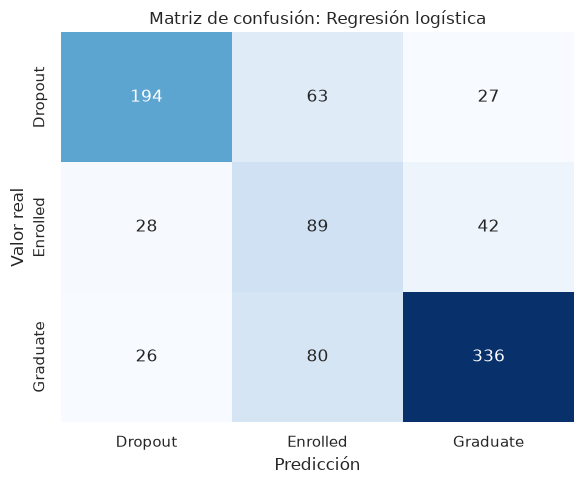

,Modelo,F1 macro (CV),Recall Dropout (CV),Accuracy (CV)
0,Random forest binario,0.827,0.716,0.854
1,Regresión logística binaria,0.827,0.796,0.846
2,Baseline binario: clase mayoritaria,0.404,0.000,0.679


,Modelo,F1 macro,Recall Dropout,Precisión Dropout,Accuracy
0,Regresión logística binaria,0.819,0.785,0.734,0.840
1,Random forest binario,0.799,0.687,0.759,0.829
2,Baseline binario: clase mayoritaria,0.404,0.000,0.000,0.679


,precision,recall,f1-score,support
Dropout,0.759,0.687,0.721,284.0
No Dropout,0.858,0.897,0.877,601.0
macro avg,0.809,0.792,0.799,885.0
weighted avg,0.826,0.829,0.827,885.0


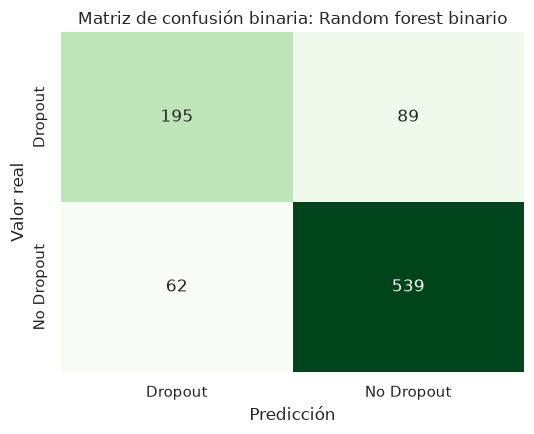

In [3]:
multiclass_test_rows = []
multiclass_fitted = {}
for name, pipeline in multiclass_pipelines.items():
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    multiclass_fitted[name] = pipeline
    multiclass_test_rows.append({
        "Modelo": name,
        "F1 macro": f1_score(y_test, predictions, average="macro"),
        "Recall Dropout": recall_score(y_test, predictions, labels=["Dropout"], average="macro", zero_division=0),
        "Precisión Dropout": precision_score(y_test, predictions, labels=["Dropout"], average="macro", zero_division=0),
        "Accuracy": accuracy_score(y_test, predictions),
    })
multiclass_test_results = pd.DataFrame(multiclass_test_rows).sort_values(
    ["F1 macro", "Recall Dropout"], ascending=False
).reset_index(drop=True)
display(multiclass_test_results.round(3))

best_multiclass_name = multiclass_cv_results.iloc[0]["Modelo"]
best_multiclass_pipeline = multiclass_fitted[best_multiclass_name]
best_multiclass_predictions = best_multiclass_pipeline.predict(X_test)
class_order = ["Dropout", "Enrolled", "Graduate"]
multiclass_report = pd.DataFrame(
    classification_report(
        y_test,
        best_multiclass_predictions,
        labels=class_order,
        output_dict=True,
        zero_division=0,
    )
).T
display(multiclass_report.loc[class_order + ["macro avg", "weighted avg"]].round(3))

fig, ax = plt.subplots(figsize=(6, 5))
multiclass_matrix = confusion_matrix(y_test, best_multiclass_predictions, labels=class_order)
sns.heatmap(
    multiclass_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=class_order, yticklabels=class_order, ax=ax,
)
ax.set(title=f"Matriz de confusión: {best_multiclass_name}", xlabel="Predicción", ylabel="Valor real")
plt.tight_layout()
plt.show()

# Formulación binaria auxiliar solicitada en el alcance del TP1.
y_train_binary = y_train.map(lambda value: "Dropout" if value == "Dropout" else "No Dropout")
y_test_binary = y_test.map(lambda value: "Dropout" if value == "Dropout" else "No Dropout")
binary_models = {
    "Baseline binario: clase mayoritaria": DummyClassifier(strategy="most_frequent"),
    "Regresión logística binaria": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42,
    ),
    "Random forest binario": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1,
    ),
}
binary_pipelines = {
    name: build_pipeline(estimator)
    for name, estimator in binary_models.items()
}
binary_scoring = {
    "f1_macro": "f1_macro",
    "recall_dropout": make_scorer(
        recall_score, pos_label="Dropout", zero_division=0,
    ),
    "accuracy": "accuracy",
}
binary_cv_rows = []
for name, pipeline in binary_pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train_binary,
        cv=cv,
        scoring=binary_scoring,
        n_jobs=1,
        error_score="raise",
    )
    binary_cv_rows.append({
        "Modelo": name,
        "F1 macro (CV)": scores["test_f1_macro"].mean(),
        "Recall Dropout (CV)": scores["test_recall_dropout"].mean(),
        "Accuracy (CV)": scores["test_accuracy"].mean(),
    })
binary_cv_results = pd.DataFrame(binary_cv_rows).sort_values(
    "F1 macro (CV)", ascending=False
).reset_index(drop=True)
display(binary_cv_results.round(3))

binary_test_rows = []
binary_fitted = {}
for name, pipeline in binary_pipelines.items():
    pipeline.fit(X_train, y_train_binary)
    predictions = pipeline.predict(X_test)
    binary_fitted[name] = pipeline
    binary_test_rows.append({
        "Modelo": name,
        "F1 macro": f1_score(y_test_binary, predictions, average="macro"),
        "Recall Dropout": recall_score(y_test_binary, predictions, pos_label="Dropout", zero_division=0),
        "Precisión Dropout": precision_score(y_test_binary, predictions, pos_label="Dropout", zero_division=0),
        "Accuracy": accuracy_score(y_test_binary, predictions),
    })
binary_test_results = pd.DataFrame(binary_test_rows).sort_values(
    ["F1 macro", "Recall Dropout"], ascending=False
).reset_index(drop=True)
display(binary_test_results.round(3))

best_binary_name = binary_cv_results.iloc[0]["Modelo"]
best_binary_pipeline = binary_fitted[best_binary_name]
best_binary_predictions = best_binary_pipeline.predict(X_test)
binary_report = pd.DataFrame(
    classification_report(
        y_test_binary,
        best_binary_predictions,
        labels=["Dropout", "No Dropout"],
        output_dict=True,
        zero_division=0,
    )
).T
display(binary_report.loc[["Dropout", "No Dropout", "macro avg", "weighted avg"]].round(3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
binary_matrix = confusion_matrix(
    y_test_binary, best_binary_predictions, labels=["Dropout", "No Dropout"]
)
sns.heatmap(
    binary_matrix, annot=True, fmt="d", cmap="Greens", cbar=False,
    xticklabels=["Dropout", "No Dropout"],
    yticklabels=["Dropout", "No Dropout"], ax=ax,
)
ax.set(title=f"Matriz de confusión binaria: {best_binary_name}", xlabel="Predicción", ylabel="Valor real")
plt.tight_layout()
plt.show()

,Modelo,F1 macro (CV),Recall Dropout (CV),Accuracy (CV),F1_macro_CV_redondeado
0,Regresión logística binaria,0.827,0.796,0.846,0.827
1,Random forest binario,0.827,0.716,0.854,0.827
2,Baseline binario: clase mayoritaria,0.404,0.000,0.679,0.404


,Modelo seleccionado por F1 macro CV (3 decimales); desempate por recall Dropout,F1 macro prueba,Recall Dropout prueba,Precisión Dropout prueba,Accuracy prueba
0,Regresión logística binaria,0.819,0.785,0.734,0.84


,precision,recall,f1-score,support
Dropout,0.734,0.785,0.759,284.0
No Dropout,0.895,0.865,0.880,601.0
macro avg,0.814,0.825,0.819,885.0
weighted avg,0.843,0.840,0.841,885.0


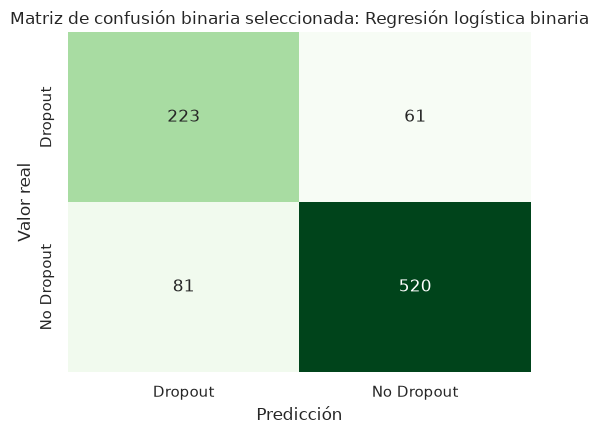

In [5]:
binary_cv_ranked = binary_cv_results.assign(
    F1_macro_CV_redondeado=binary_cv_results["F1 macro (CV)"].round(3)
).sort_values(
    ["F1_macro_CV_redondeado", "Recall Dropout (CV)"],
    ascending=False,
).reset_index(drop=True)
selected_binary_name = binary_cv_ranked.iloc[0]["Modelo"]
selected_binary_pipeline = binary_fitted[selected_binary_name]
selected_binary_predictions = selected_binary_pipeline.predict(X_test)
selected_binary_test_metrics = pd.DataFrame([{
    "Modelo seleccionado por F1 macro CV (3 decimales); desempate por recall Dropout": selected_binary_name,
    "F1 macro prueba": f1_score(y_test_binary, selected_binary_predictions, average="macro"),
    "Recall Dropout prueba": recall_score(y_test_binary, selected_binary_predictions, pos_label="Dropout", zero_division=0),
    "Precisión Dropout prueba": precision_score(y_test_binary, selected_binary_predictions, pos_label="Dropout", zero_division=0),
    "Accuracy prueba": accuracy_score(y_test_binary, selected_binary_predictions),
}])
display(binary_cv_ranked.round(3))
display(selected_binary_test_metrics.round(3))

selected_binary_report = pd.DataFrame(
    classification_report(
        y_test_binary,
        selected_binary_predictions,
        labels=["Dropout", "No Dropout"],
        output_dict=True,
        zero_division=0,
    )
).T
display(selected_binary_report.loc[["Dropout", "No Dropout", "macro avg", "weighted avg"]].round(3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
selected_binary_matrix = confusion_matrix(
    y_test_binary, selected_binary_predictions, labels=["Dropout", "No Dropout"]
)
sns.heatmap(
    selected_binary_matrix, annot=True, fmt="d", cmap="Greens", cbar=False,
    xticklabels=["Dropout", "No Dropout"],
    yticklabels=["Dropout", "No Dropout"], ax=ax,
)
ax.set(title=f"Matriz de confusión binaria seleccionada: {selected_binary_name}", xlabel="Predicción", ylabel="Valor real")
plt.tight_layout()
plt.show()

### Interpretación de los resultados

**Baseline multiclase.** `DummyClassifier` alcanza accuracy 0,499 por predecir siempre `Graduate`, pero su recall de `Dropout` es 0 y su F1 macro 0,222. La accuracy por sí sola habría ocultado que no identifica a ningún desertor.

**Modelos multiclase.** En 5-fold CV, logística y random forest obtienen F1 macro medio cercano a 0,679; el recall medio de `Dropout` es 0,708 para logística y 0,737 para random forest. En prueba, logística alcanza F1 macro 0,659, recall de `Dropout` 0,683 y precisión de `Dropout` 0,782. Random forest alcanza F1 macro 0,651, recall 0,725 y precisión 0,760. Por tanto, random forest detecta más desertores, mientras logística tiene mejor equilibrio macro y menos falsas alertas relativas entre sus alertas.

La matriz de confusión de logística muestra que `Enrolled` es la clase más difícil: F1 0,455, frente a 0,729 para `Dropout` y 0,793 para `Graduate`. De los 159 casos `Enrolled` de prueba, 89 se clasifican correctamente; 42 se predicen como `Graduate` y 28 como `Dropout`.

**Alternativa binaria.** En CV, los dos modelos alcanzan F1 macro 0,827 al redondear a tres decimales. Bajo ese empate de presentación, se usa recall de `Dropout` como criterio de desempate, coherente con el objetivo de alerta: logística (0,796) supera a random forest (0,716). En prueba, la logística binaria alcanza F1 macro 0,819, recall de `Dropout` 0,785, precisión 0,734 y accuracy 0,840. Detecta 223 de 284 desertores (61 quedan sin detectar) y genera 81 falsas alertas sobre estudiantes `No Dropout`.

La formulación binaria obtiene un resumen más alto que la multiclase, pero responde una pregunta más acotada: no distingue `Enrolled` de `Graduate`. La elección final depende de si esa distinción es necesaria para el uso del listado de acompañamiento.

### Alcance y próximos pasos

Estos resultados son preliminares: se usó una partición fija y configuraciones iniciales, sin búsqueda de hiperparámetros ni intervalos de incertidumbre. En el TF1 conviene realizar ajuste mediante validación cruzada dentro de entrenamiento, analizar errores por segmentos y calibrar un umbral de alerta con el equipo usuario. `Enrolled` es un estado ambiguo, los datos proceden de una institución portuguesa y las asociaciones del modelo no permiten afirmar causalidad ni generalizar directamente a UPC/Perú. Las variables del segundo semestre permanecen excluidas por disponibilidad temporal.